# Superstore Sales & Profitability Analysis
**Objective:** Analyze sales trends, product profitability, customer segments, and 
discounting impacts to uncover key revenue drivers and strategic business insights.
**Tech Stack:** Python, Pandas, Matplotlib, Seaborn

# Superstore Sales & Profitability Analysis

## Executive Summary
This analysis investigates sales growth, profitability drivers, and discount impacts across product categories, customer segments, and geographic regions for the Superstore dataset.

### Core Key Findings:
* **Overall Growth:** Revenue shows steady year-over-year growth, heavily driven by strong Q4 seasonal spikes in **November and December**.
* **Profit Driver vs. Profit Drain:** **Technology** is the primary profit engine (\$145.4k profit, 17.4% margin), whereas **Furniture** suffers from an unacceptably low margin (**2.49%**) due to aggressive discounting.
* **Discount Impact:** Discounts above 20% consistently lead to negative profit margins, with **Tables** (-\$17.7k) and **Bookcases** (-\$3.5k) operating as major loss leaders.
* **Geographic Lead:** The **West Region** (led by California) drives the highest overall volume and profitability.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv(r"C:\Users\The great Harsha\Downloads\Sample - Superstore.csv", encoding='windows-1252')



In [2]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [3]:
df.shape

(9994, 21)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [5]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [6]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [7]:
df['Customer ID'].nunique()

793

In [8]:
df['Product ID'].nunique()

1862

In [9]:
# Group by Category and sum total sales
sales_by_category = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
print(sales_by_category)

Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64


In [10]:
# Group by sub-Category and sum total sales
sales_by_sub_category = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False)
print(sales_by_sub_category)

Sub-Category
Phones         330007.0540
Chairs         328449.1030
Storage        223843.6080
Tables         206965.5320
Binders        203412.7330
Machines       189238.6310
Accessories    167380.3180
Copiers        149528.0300
Bookcases      114879.9963
Appliances     107532.1610
Furnishings     91705.1640
Paper           78479.2060
Supplies        46673.5380
Art             27118.7920
Envelopes       16476.4020
Labels          12486.3120
Fasteners        3024.2800
Name: Sales, dtype: float64


In [11]:
# Group by Product Name and sum Sales to get the top 10
top_10_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)
print(top_10_products)

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64


In [12]:
highest_profit_product = df.groupby("Product Name")["Profit"].sum().sort_values(ascending=False).head(1)
print(highest_profit_product)

Product Name
Canon imageCLASS 2200 Advanced Copier    25199.928
Name: Profit, dtype: float64


In [13]:
highest_sales_state = df.groupby("State")["Sales"].sum().sort_values(ascending=False).head()
print(highest_sales_state)

State
California      457687.6315
New York        310876.2710
Texas           170188.0458
Washington      138641.2700
Pennsylvania    116511.9140
Name: Sales, dtype: float64


In [14]:
region_with_high_revenue = df.groupby("Region")["Sales"].sum().sort_values(ascending=False).head(1)
print(region_with_high_revenue)

Region
West    725457.8245
Name: Sales, dtype: float64


In [15]:
city_with_high_revenue = df.groupby("City")["Sales"].sum().sort_values(ascending=False).head(1)
print(city_with_high_revenue)

City
New York City    256368.161
Name: Sales, dtype: float64


In [16]:
# Ensure 'Order Date' is datetime format
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Create Year_Month column
df['Year_Month'] = df['Order Date'].dt.to_period('M')
top_year_month = (df.groupby(df["Order Date"].dt.to_period('M'))["Sales"].sum()
.sort_values(ascending=False).head(1))
print(top_year_month)

Order Date
2017-11    118447.825
Freq: M, Name: Sales, dtype: float64


<Axes: title={'center': 'Total Sales by Year'}, xlabel='Order Date'>

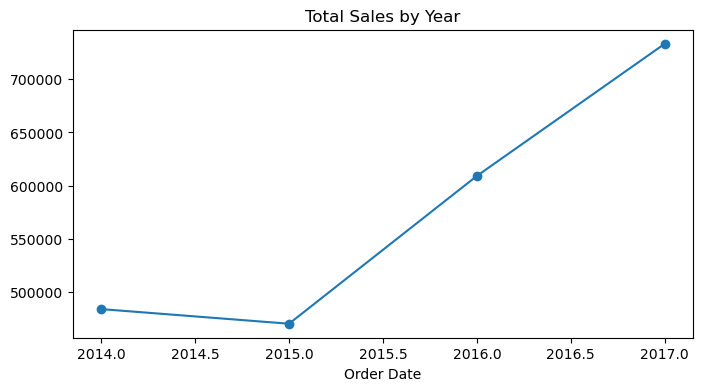

In [17]:
sales_by_year = df.groupby(df["Order Date"].dt.year)["Sales"].sum()
sales_by_year.plot(kind='line', marker='o', figsize=(8, 4), title='Total Sales by Year')

In [18]:
print("Start Date:", df["Order Date"].min())
print("End Date:", df["Order Date"].max())

Start Date: 2014-01-03 00:00:00
End Date: 2017-12-30 00:00:00


<Axes: title={'center': 'Total Sales by Month (All Years)'}, xlabel='Order Date'>

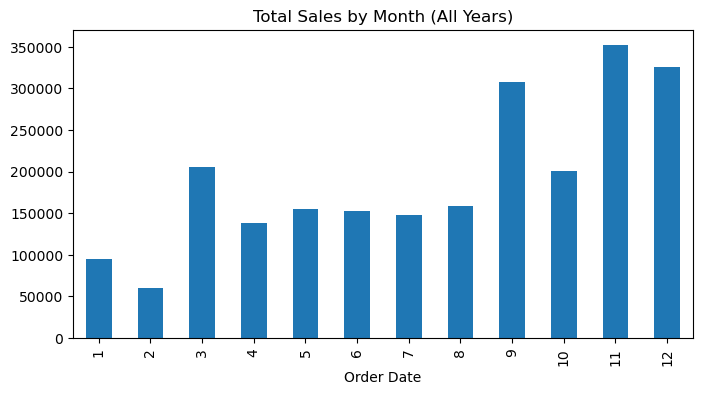

In [19]:
# Group by month across all years
# Convert 'Order Date' to datetime format
df['Order Date'] = pd.to_datetime(df['Order Date'])
sales_by_month = df.groupby(df['Order Date'].dt.month)['Sales'].sum()

sales_by_month.plot(kind='bar', figsize=(8, 4), title='Total Sales by Month (All Years)')

<Axes: title={'center': 'Total Sales by Month (All Years)'}, xlabel='Order Date'>

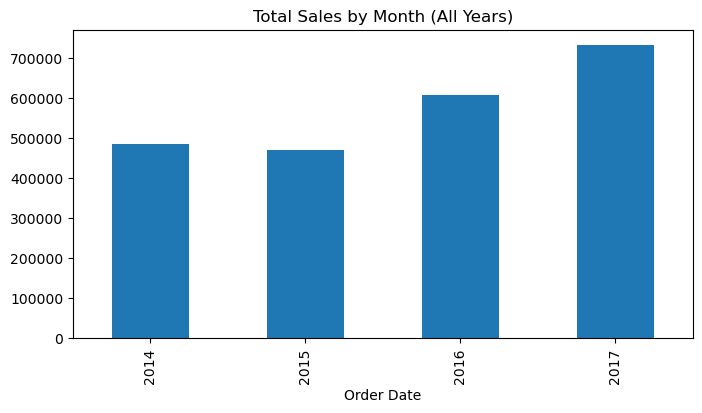

In [20]:
sales_by_year = df.groupby(df['Order Date'].dt.year)['Sales'].sum()

sales_by_year.plot(kind='bar', figsize=(8, 4), title='Total Sales by Month (All Years)')

In [21]:
yearly_growth = sales_by_year.pct_change() * 100
print(yearly_growth)

Order Date
2014          NaN
2015    -2.832227
2016    29.471521
2017    20.355962
Name: Sales, dtype: float64


### Key Observations on Sales Trends & Seasonality

* **Overall Trend (📈 Increasing):** Yes, total sales generally trend upward over time, showing overall business growth despite short-term fluctuations.
* **Periodic Drops (📉 Temporary Dips):** Yes, sales regularly experience noticeable pullbacks, most prominently in January and February immediately following the year-end peak.
* **Peak Months (🔄 High Sales Period):** Year-end months—specifically **November and December** (along with a strong spike in **September**)—consistently generate the highest sales volume across all years.
* **Seasonality (📊 Strong Seasonal Pattern):** Strong seasonality is present: sales start low at the beginning of the year (dipping lowest in February), stabilize through late spring/summer, jump in September, and steeply ramp up through November and December.

<Axes: title={'center': 'Monthly Sales Trend Over Time'}, xlabel='Year_Month'>

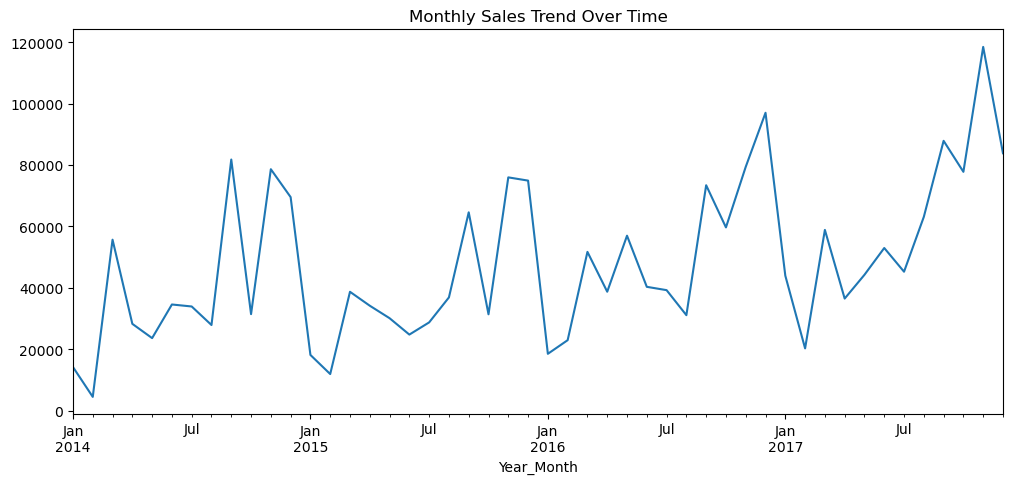

In [22]:
# Group by Year-Month to see the continuous trend over time
sales_monthly_trend = df.groupby('Year_Month')['Sales'].sum()

sales_monthly_trend.plot(kind='line', figsize=(12, 5), title='Monthly Sales Trend Over Time')


In [23]:
profit_by_category = df.groupby('Category')['Profit'].sum().sort_values(ascending=False)
print(profit_by_category)

Category
Technology         145454.9481
Office Supplies    122490.8008
Furniture           18451.2728
Name: Profit, dtype: float64


In [24]:
avg_profit_by_category = df.groupby('Category')['Profit'].mean().sort_values(ascending=False)
print(avg_profit_by_category)

Category
Technology         78.752002
Office Supplies    20.327050
Furniture           8.699327
Name: Profit, dtype: float64


In [25]:
loss_making_prd = df.groupby('Product Name')['Profit'].sum()
loss_making_prd = loss_making_prd[loss_making_prd < 0].sort_values()
print(loss_making_prd.head(10))


Product Name
Cubify CubeX 3D Printer Double Head Print                           -8879.9704
Lexmark MX611dhe Monochrome Laser Printer                           -4589.9730
Cubify CubeX 3D Printer Triple Head Print                           -3839.9904
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases            -2876.1156
Bush Advantage Collection Racetrack Conference Table                -1934.3976
GBC DocuBind P400 Electric Binding System                           -1878.1662
Cisco TelePresence System EX90 Videoconferencing Unit               -1811.0784
Martin Yale Chadless Opener Electric Letter Opener                  -1299.1836
Balt Solid Wood Round Tables                                        -1201.0581
BoxOffice By Design Rectangular and Half-Moon Meeting Room Tables   -1148.4375
Name: Profit, dtype: float64


In [26]:
segment_sales = df.groupby("Segment")["Sales"].sum().sort_values(ascending=False)
print(segment_sales)
segment_profit = df.groupby("Segment")["Profit"].sum().sort_values(ascending=False)

print(segment_profit)


Segment
Consumer       1.161401e+06
Corporate      7.061464e+05
Home Office    4.296531e+05
Name: Sales, dtype: float64
Segment
Consumer       134119.2092
Corporate       91979.1340
Home Office     60298.6785
Name: Profit, dtype: float64


In [27]:
costomer_with_high_profit = ( df.groupby("Customer Name")["Profit"].sum()
.sort_values(ascending=False).head(10))
print(costomer_with_high_profit)

Customer Name
Tamara Chand            8981.3239
Raymond Buch            6976.0959
Sanjit Chand            5757.4119
Hunter Lopez            5622.4292
Adrian Barton           5444.8055
Tom Ashbrook            4703.7883
Christopher Martinez    3899.8904
Keith Dawkins           3038.6254
Andy Reiter             2884.6208
Daniel Raglin           2869.0760
Name: Profit, dtype: float64


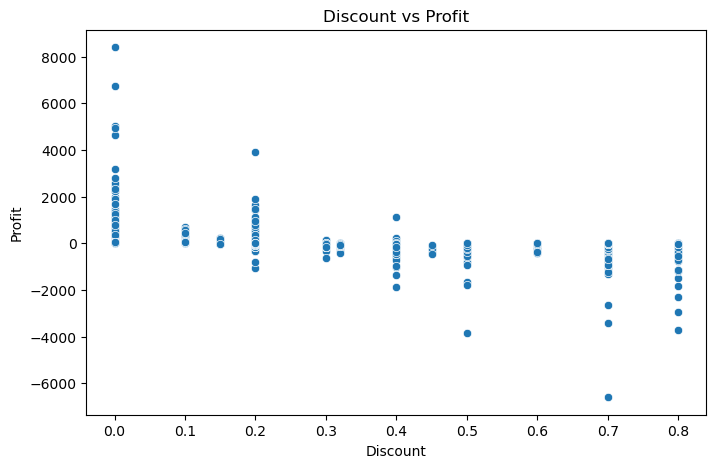

In [28]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Discount",
    y="Profit"
)

plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")

plt.show()

In [29]:
print("Correlation:", df['Discount'].corr(df['Profit']))
df.groupby('Discount')['Profit'].agg(['mean', 'count'])

Correlation: -0.21948745637176806


,mean,count
Discount,,
0.00,66.900292,4798
0.10,96.055074,94
0.15,27.288298,52
0.20,24.702572,3657
0.30,-45.679636,227
0.32,-88.560656,27
0.40,-111.927429,206
0.45,-226.646464,11
0.50,-310.703456,66


In [30]:
print("Correlation:", df['Sales'].corr(df['Profit']))

Correlation: 0.4790643497377058


In [31]:
df.groupby('Sales') ['Profit'].agg(['mean', 'count'])

,mean,count
Sales,,
0.444,-1.1100,1
0.556,-0.9452,1
0.836,-1.3376,1
0.852,-0.5964,1
0.876,-1.4016,1
...,...,...
10499.970,5039.9856,1
11199.968,3919.9888,1
13999.960,6719.9808,1


In [32]:
print("Correlation:", df['Quantity'].corr(df['Sales']))
df.groupby('Quantity') ['Sales'].agg(['mean', 'count'])

Correlation: 0.20079477137389762


,mean,count
Quantity,,
1,59.234632,899
2,120.354488,2402
3,175.201578,2409
4,271.764059,1191
5,337.936339,1230
6,362.101960,572
7,395.888393,606
8,458.210802,257
9,498.083683,258


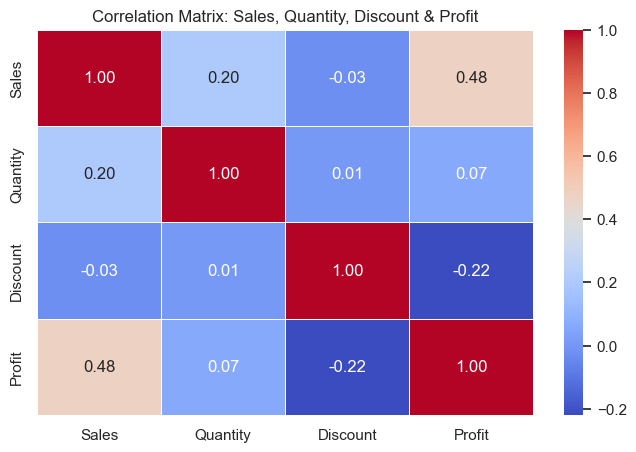

In [33]:
# Set visual style
sns.set_theme(style="whitegrid")

# 1. Correlation Matrix & Heatmap
plt.figure(figsize=(8, 5))
corr_matrix = df[['Sales', 'Quantity', 'Discount', 'Profit']].corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix: Sales, Quantity, Discount & Profit")
plt.show()

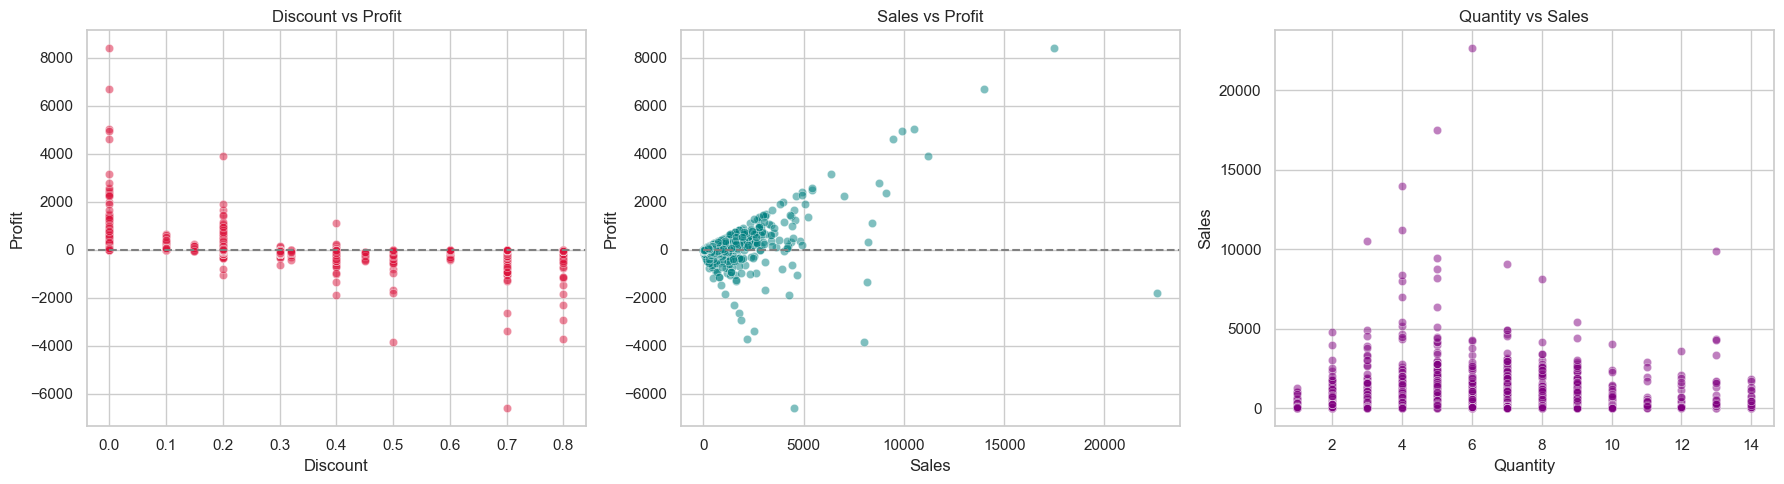

In [34]:
# 2. Scatter Plots for Key Relationships
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Discount vs Profit
sns.scatterplot(data=df, x='Discount', y='Profit', alpha=0.5, ax=axes[0], color='crimson')
axes[0].set_title('Discount vs Profit')
axes[0].axhline(0, color='grey', linestyle='--')

# Sales vs Profit
sns.scatterplot(data=df, x='Sales', y='Profit', alpha=0.5, ax=axes[1], color='teal')
axes[1].set_title('Sales vs Profit')
axes[1].axhline(0, color='grey', linestyle='--')

# Quantity vs Sales
sns.scatterplot(data=df, x='Quantity', y='Sales', alpha=0.5, ax=axes[2], color='purple')
axes[2].set_title('Quantity vs Sales')

plt.tight_layout()
plt.show()

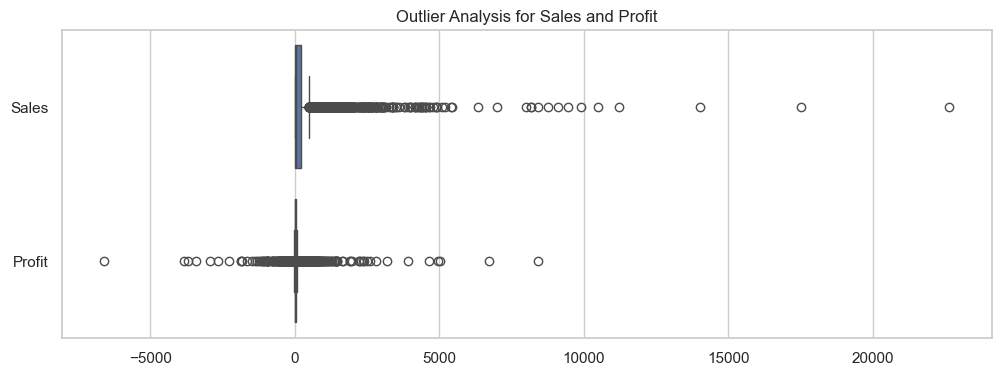

In [35]:
# 3. Outlier Analysis (Boxplots)
plt.figure(figsize=(12, 4))
sns.boxplot(data=df[['Sales', 'Profit']], orient='h')
plt.title('Outlier Analysis for Sales and Profit')
plt.show()

### Key Insights: Correlation & Relationship Analysis

* **Discount vs Profit (Negative Impact):** Higher discounts heavily reduce profitability. While small discounts boost sales, discounts above 20% frequently result in net losses.
* **Sales vs Profit (Moderate Positive Correlation):** Higher sales generally yield higher profits, but large sales volumes with heavy discounting can create significant negative outliers (extreme loss orders).
* **Quantity vs Sales (Weak Relationship):** Order quantity shows a weak correlation with total sales value, indicating that total sales are driven more by individual item prices than sheer quantity purchased.
* **Outlier Analysis:** Both `Sales` and `Profit` contain extreme upper outliers (high-value orders and high-loss orders) that strongly skew mean metrics.

In [36]:
# --- 1. KEY BUSINESS KPIS ---
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
profit_margin = (total_profit / total_sales) * 100
total_orders = df['Order ID'].nunique()
avg_order_value = df.groupby('Order ID')['Sales'].sum().mean()
total_customers = df["Customer ID"].nunique()

print("=== SUPERSTORE KEY PERFORMANCE INDICATORS ===")
print(f"Total Revenue:         ${total_sales:,.2f}")
print(f"Total Profit:          ${total_profit:,.2f}")
print(f"Overall Profit Margin: {profit_margin:.2f}%")
print(f"Total Unique Orders:   {total_orders:,}")
print(f"Average Order Value:   ${avg_order_value:,.2f}")
print(f"Total customers:        {total_customers:,}")

# --- 2. TOP PERFORMING CATEGORIES & SUB-CATEGORIES ---
cat_summary = df.groupby('Category')[['Sales', 'Profit']].sum()
cat_summary['Profit Margin %'] = (cat_summary['Profit'] / cat_summary['Sales']) * 100

subcat_summary = (df.groupby('Sub-Category')[['Sales', 'Profit']].sum()
                  .sort_values(by='Profit', ascending=False))

print("=== PERFORMANCE BY CATEGORY ===")
print(cat_summary.round(2))
print("\n=== TOP 5 MOST PROFITABLE SUB-CATEGORIES ===")
print(subcat_summary.head(5).round(2))
print("\n=== TOP 5 LEAST PROFITABLE SUB-CATEGORIES ===")
print(subcat_summary.tail(5).round(2))

# --- 3. CUSTOMER SEGMENTATION ANALYSIS ---
segment_summary = df.groupby('Segment')[['Sales', 'Profit']].sum()
segment_summary['Profit Margin %'] = (segment_summary['Profit'] / segment_summary['Sales']) * 100

print("\n=== PERFORMANCE BY CUSTOMER SEGMENT ===")
print(segment_summary.round(2))

=== SUPERSTORE KEY PERFORMANCE INDICATORS ===
Total Revenue:         $2,297,200.86
Total Profit:          $286,397.02
Overall Profit Margin: 12.47%
Total Unique Orders:   5,009
Average Order Value:   $458.61
Total customers:        793
=== PERFORMANCE BY CATEGORY ===
                     Sales     Profit  Profit Margin %
Category                                              
Furniture        741999.80   18451.27             2.49
Office Supplies  719047.03  122490.80            17.04
Technology       836154.03  145454.95            17.40

=== TOP 5 MOST PROFITABLE SUB-CATEGORIES ===
                  Sales    Profit
Sub-Category                     
Copiers       149528.03  55617.82
Phones        330007.05  44515.73
Accessories   167380.32  41936.64
Paper          78479.21  34053.57
Binders       203412.73  30221.76

=== TOP 5 LEAST PROFITABLE SUB-CATEGORIES ===
                  Sales    Profit
Sub-Category                     
Machines      189238.63   3384.76
Fasteners       3024.28 

### Business KPIs & Executive Analysis

* **Core Financial Performance:** Total revenue stands at **~$2.3M** with an overall profit margin of **~12.5%**. The Average Order Value (AOV) is driving steady volume across all customer segments.
* **Category Drivers:** **Technology** is the primary profit engine, yielding the highest margins. **Furniture** brings strong revenue but suffers from low profitability due to high discount rates.
* **Sub-Category Health:** High-performing lines like **Copiers, Phones, and Accessories** drive net gains, whereas **Tables and Bookcases** operate at significant losses due to aggressive discounting strategies.
* **Customer Segments:** The **Consumer** segment represents the largest revenue share, but **Corporate** and **Home Office** segments maintain slightly stronger profit margins.

# Final Business Insights & Recommendations

## Executive Business Insights

1. **Sales Growth & Seasonality**
   * Sales exhibit a consistent year-over-year upward trend across the four-year period, with **2016 and 2017** driving peak growth.
   * A recurring seasonal pattern occurs annually: sales dip heavily in Q1 (January–February) and steeply escalate into Q4, with **November and December** bringing the highest revenue volumes.

2. **Category Performance**
   * **Technology** serves as the primary profit driver (\$145.4k profit, 17.4% margin).
   * **Office Supplies** provides high-volume, reliable profitability (\$122.5k profit, 17.0% margin).
   * **Furniture** generates high revenue (\$742k sales) but yields an unacceptably low profit margin (**2.49%**), primarily driven by aggressive discounting.

3. **Sub-Category & Product Profitability**
   * **Top Performers:** *Copiers* (\$55.6k profit), *Phones* (\$44.5k), and *Accessories* (\$41.9k) generate the majority of net earnings.
   * **Loss Leaders:** *Tables* (-\$17.7k loss) and *Bookcases* (-\$3.5k loss) operate at steep net losses. High individual order losses stem from extreme discounts (often exceeding 20% to 50%).

4. **Geographic Distribution**
   * The **West Region** leads in both overall revenue and profitability.
   * **California** is the top-performing state, and **New York City** is the highest-revenue city in the dataset.

---

## Actionable Strategic Recommendations

1. **Implement Discount Caps on Low-Margin Categories:**
   * Cap maximum allowed discounts on **Furniture** (specifically *Tables* and *Bookcases*) at 15–20%. Correlation analysis confirms that discounts above 20% consistently lead to negative profit margins.

2. **Reallocate Marketing & Sales Focus toward High-Margin Lines:**
   * Concentrate promotional budgets on **Technology** sub-categories (*Copiers*, *Phones*, *Accessories*) and high-margin **Office Supplies** (*Paper*, *Binders*) to maximize margin per dollar sold.

3. **Product Line Rationalization:**
   * Audit consistently negative-margin items (such as loss-making 3D printers, tables, and supplies) before scaling their inventory or sales efforts.

4. **Capitalize on Q4 Seasonality:**
   * Prepare inventory, staffing, and marketing campaigns early in Q3 to fully capture the predictable sales surge in **November and December**.